In [3]:
import pandas as pd

df = pd.read_csv("/content/featured_violations.csv")

print(df.shape)
df.head()

(298450, 26)


,id,latitude,longitude,location,vehicle_number,vehicle_type,violation_type,offence_code,created_datetime,modified_datetime,...,data_sent_to_scita_timestamp,updated_vehicle_number,updated_vehicle_type,validation_status,validation_timestamp,hour,day_of_week,month,weekend,peak_hour
0,FKID000000,12.925557,77.618665,"18th Main Road, Block 2, Koramangala, Bengalur...",FKN00GL0000,CAR,"[""WRONG PARKING"",""PARKING NEAR ROAD CROSSING""]","[112,104]",2023-11-20 00:28:46+00:00,2023-11-28 04:48:04.582978+00,...,NaN,FKN00GL0000,MAXI-CAB,approved,2023-11-30 03:08:24.818+00,0.0,Monday,11.0,False,False
1,FKID000001,12.905463,77.700778,"Sarjapura Main Road, The Grove, Janatha Colony...",FKN00GL0001,CAR,"[""NO PARKING""]",[113],2023-11-24 22:46:46+00:00,2023-11-24 23:00:24.115257+00,...,NaN,NaN,NaN,NaN,NaN,22.0,Friday,11.0,False,False
2,FKID000002,12.925449,77.618504,"Koramangala 2nd Block, Kormangala West, Bengal...",FKN00GL0002,CAR,"[""WRONG PARKING"",""PARKING IN A MAIN ROAD""]","[112,107]",2023-11-20 00:27:46+00:00,2023-11-28 04:47:02.33776+00,...,NaN,FKN00GL0002,MAXI-CAB,approved,2023-11-30 03:08:56.998+00,0.0,Monday,11.0,False,False
3,FKID000003,12.956521,77.518618,"6th Cross Road, Manasa Layout, Nagarbhavi, Ben...",FKN00GL0003,SCOOTER,"[""NO PARKING""]",[113],2023-11-16 06:47:46+00:00,2023-11-18 04:46:57.216868+00,...,NaN,FKN00GL0003,SCOOTER,approved,2023-11-18 23:35:12.428+00,6.0,Thursday,11.0,False,False
4,FKID000004,12.977767,77.580545,"Kalidasa Road, Gandhinagar, Nehru Nagar, Benga...",FKN00GL0004,TANKER,"[""NO PARKING""]",[113],2023-11-22 04:56:46+00:00,2023-11-28 02:44:50.46737+00,...,NaN,FKN00GL0004,TANKER,approved,2023-11-30 03:11:32.796+00,4.0,Wednesday,11.0,False,False


In [4]:
df["created_datetime"] = pd.to_datetime(
    df["created_datetime"],
    errors="coerce"
)

df["date"] = df["created_datetime"].dt.date

print(df[["created_datetime","date"]].head())

           created_datetime        date
0 2023-11-20 00:28:46+00:00  2023-11-20
1 2023-11-24 22:46:46+00:00  2023-11-24
2 2023-11-20 00:27:46+00:00  2023-11-20
3 2023-11-16 06:47:46+00:00  2023-11-16
4 2023-11-22 04:56:46+00:00  2023-11-22


In [5]:
daily_counts = (
    df.groupby(["location","date"])
      .size()
      .reset_index(name="violation_count")
)

print(daily_counts.shape)
daily_counts.head()

(73613, 3)


,location,date,violation_count
0,"1, 10th Main Road, Achaiah Chetty Layout, Sada...",2023-11-19,1
1,"1, 12th Main Road, Sector 6, HSR Layout, Benga...",2023-12-01,1
2,"1, 14th Main Road, Sector 7, HSR Layout, Benga...",2023-12-07,6
3,"1, 7th C Cross Road, Maistripalaya, Kormangala...",2024-04-03,1
4,"1/1, East Park Road, Sadashivanagar, Sadashiva...",2023-12-26,1


In [6]:
print(daily_counts.shape)

(73613, 3)


In [7]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(
    contamination=0.02,
    random_state=42
)

daily_counts["anomaly"] = model.fit_predict(
    daily_counts[["violation_count"]]
)

daily_counts.head()

,location,date,violation_count,anomaly
0,"1, 10th Main Road, Achaiah Chetty Layout, Sada...",2023-11-19,1,1
1,"1, 12th Main Road, Sector 6, HSR Layout, Benga...",2023-12-01,1,1
2,"1, 14th Main Road, Sector 7, HSR Layout, Benga...",2023-12-07,6,1
3,"1, 7th C Cross Road, Maistripalaya, Kormangala...",2024-04-03,1,1
4,"1/1, East Park Road, Sadashivanagar, Sadashiva...",2023-12-26,1,1


In [8]:
daily_counts["anomaly"].value_counts()

,count
anomaly,
1,72178
-1,1435


In [9]:
anomalies = daily_counts[
    daily_counts["anomaly"] == -1
]

print(anomalies.shape)

anomalies.head()

(1435, 4)


,location,date,violation_count,anomaly
248,"10th Cross Road, Block 1, Rajaji Nagar, Bengal...",2023-11-18,95,-1
257,"10th Cross Road, Block 1, Rajaji Nagar, Bengal...",2023-11-27,35,-1
258,"10th Cross Road, Block 1, Rajaji Nagar, Bengal...",2023-11-28,52,-1
259,"10th Cross Road, Block 1, Rajaji Nagar, Bengal...",2023-11-29,77,-1
262,"10th Cross Road, Block 1, Rajaji Nagar, Bengal...",2023-12-04,121,-1


In [10]:
top_anomalies = anomalies.sort_values(
    by="violation_count",
    ascending=False
)

top_anomalies.head(20)

,location,date,violation_count,anomaly
52935,"New Horizon College Road, New Horizon College ...",2024-02-23,247,-1
27072,"Chord Road, Manuvana, Vijaya Nagar, Bengaluru,...",2024-03-12,207,-1
51476,"Mysore Road, Sri Krishna Rajendra Market, Chic...",2024-01-25,181,-1
52951,"New Horizon College Road, New Horizon College ...",2024-03-15,171,-1
52909,"New Horizon College Road, New Horizon College ...",2024-01-11,169,-1
30300,"Dickenson Road, Sri Nagamma Devi Circle, Sivan...",2024-01-07,144,-1
52815,"New Horizon College Road, Embassy Tech Village...",2024-01-16,142,-1
52816,"New Horizon College Road, Embassy Tech Village...",2024-01-17,139,-1
52811,"New Horizon College Road, Embassy Tech Village...",2024-01-11,133,-1
61940,"Sahakar Nagar Road, Fortuna Acacia, Byatarayan...",2024-02-10,132,-1


In [11]:
anomalies.to_csv(
    "anomalies.csv",
    index=False
)

print("Saved")

Saved


In [12]:
top_anomalies.head(20)

,location,date,violation_count,anomaly
52935,"New Horizon College Road, New Horizon College ...",2024-02-23,247,-1
27072,"Chord Road, Manuvana, Vijaya Nagar, Bengaluru,...",2024-03-12,207,-1
51476,"Mysore Road, Sri Krishna Rajendra Market, Chic...",2024-01-25,181,-1
52951,"New Horizon College Road, New Horizon College ...",2024-03-15,171,-1
52909,"New Horizon College Road, New Horizon College ...",2024-01-11,169,-1
30300,"Dickenson Road, Sri Nagamma Devi Circle, Sivan...",2024-01-07,144,-1
52815,"New Horizon College Road, Embassy Tech Village...",2024-01-16,142,-1
52816,"New Horizon College Road, Embassy Tech Village...",2024-01-17,139,-1
52811,"New Horizon College Road, Embassy Tech Village...",2024-01-11,133,-1
61940,"Sahakar Nagar Road, Fortuna Acacia, Byatarayan...",2024-02-10,132,-1


In [13]:
daily_counts.to_csv(
    "daily_counts.csv",
    index=False
)



print("Files saved successfully")

Files saved successfully


In [14]:
anomalies.describe()

,violation_count,anomaly
count,1435.000000,1435.0
mean,42.249477,-1.0
std,20.683891,0.0
min,26.000000,-1.0
25%,29.000000,-1.0
50%,35.000000,-1.0
75%,47.000000,-1.0
max,247.000000,-1.0


In [15]:
anomalies["violation_count"].describe()

,violation_count
count,1435.000000
mean,42.249477
std,20.683891
min,26.000000
25%,29.000000
50%,35.000000
75%,47.000000
max,247.000000


In [16]:
anomalies["severity"] = anomalies["violation_count"].apply(
    lambda x: "HIGH" if x > 150
    else "MEDIUM" if x > 80
    else "LOW"
)

anomalies.head()

/tmp/ipykernel_1301/1272881300.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  anomalies["severity"] = anomalies["violation_count"].apply(


,location,date,violation_count,anomaly,severity
248,"10th Cross Road, Block 1, Rajaji Nagar, Bengal...",2023-11-18,95,-1,MEDIUM
257,"10th Cross Road, Block 1, Rajaji Nagar, Bengal...",2023-11-27,35,-1,LOW
258,"10th Cross Road, Block 1, Rajaji Nagar, Bengal...",2023-11-28,52,-1,LOW
259,"10th Cross Road, Block 1, Rajaji Nagar, Bengal...",2023-11-29,77,-1,LOW
262,"10th Cross Road, Block 1, Rajaji Nagar, Bengal...",2023-12-04,121,-1,MEDIUM


In [17]:
anomalies["alert"] = (
    "Violation spike detected at "
    + anomalies["location"]
)

/tmp/ipykernel_1301/4064850975.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  anomalies["alert"] = (


In [18]:
anomalies.to_csv(
    "anomaly_alerts.csv",
    index=False
)

In [19]:
anomalies["severity"] = anomalies["violation_count"].apply(
    lambda x: "CRITICAL" if x >= 200
    else "HIGH" if x >= 100
    else "MEDIUM"
)

anomalies.head()

/tmp/ipykernel_1301/5075514.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  anomalies["severity"] = anomalies["violation_count"].apply(


,location,date,violation_count,anomaly,severity,alert
248,"10th Cross Road, Block 1, Rajaji Nagar, Bengal...",2023-11-18,95,-1,MEDIUM,"Violation spike detected at 10th Cross Road, B..."
257,"10th Cross Road, Block 1, Rajaji Nagar, Bengal...",2023-11-27,35,-1,MEDIUM,"Violation spike detected at 10th Cross Road, B..."
258,"10th Cross Road, Block 1, Rajaji Nagar, Bengal...",2023-11-28,52,-1,MEDIUM,"Violation spike detected at 10th Cross Road, B..."
259,"10th Cross Road, Block 1, Rajaji Nagar, Bengal...",2023-11-29,77,-1,MEDIUM,"Violation spike detected at 10th Cross Road, B..."
262,"10th Cross Road, Block 1, Rajaji Nagar, Bengal...",2023-12-04,121,-1,HIGH,"Violation spike detected at 10th Cross Road, B..."


In [20]:
anomalies["alert_message"] = (
    "Parking violation spike detected at "
    + anomalies["location"]
)

/tmp/ipykernel_1301/2873828718.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  anomalies["alert_message"] = (


In [21]:
anomalies = anomalies.reset_index(drop=True)

anomalies["alert_id"] = [
    f"ALT{i+1:04d}"
    for i in range(len(anomalies))
]

In [22]:
alerts = anomalies[
    [
        "alert_id",
        "location",
        "date",
        "violation_count",
        "severity",
        "alert_message"
    ]
]

alerts.head()

,alert_id,location,date,violation_count,severity,alert_message
0,ALT0001,"10th Cross Road, Block 1, Rajaji Nagar, Bengal...",2023-11-18,95,MEDIUM,Parking violation spike detected at 10th Cross...
1,ALT0002,"10th Cross Road, Block 1, Rajaji Nagar, Bengal...",2023-11-27,35,MEDIUM,Parking violation spike detected at 10th Cross...
2,ALT0003,"10th Cross Road, Block 1, Rajaji Nagar, Bengal...",2023-11-28,52,MEDIUM,Parking violation spike detected at 10th Cross...
3,ALT0004,"10th Cross Road, Block 1, Rajaji Nagar, Bengal...",2023-11-29,77,MEDIUM,Parking violation spike detected at 10th Cross...
4,ALT0005,"10th Cross Road, Block 1, Rajaji Nagar, Bengal...",2023-12-04,121,HIGH,Parking violation spike detected at 10th Cross...


In [23]:
alerts.to_csv(
    "anomaly_alerts.csv",
    index=False
)

print("Alert file generated")

Alert file generated


In [24]:
alerts.head(20)

,alert_id,location,date,violation_count,severity,alert_message
0,ALT0001,"10th Cross Road, Block 1, Rajaji Nagar, Bengal...",2023-11-18,95,MEDIUM,Parking violation spike detected at 10th Cross...
1,ALT0002,"10th Cross Road, Block 1, Rajaji Nagar, Bengal...",2023-11-27,35,MEDIUM,Parking violation spike detected at 10th Cross...
2,ALT0003,"10th Cross Road, Block 1, Rajaji Nagar, Bengal...",2023-11-28,52,MEDIUM,Parking violation spike detected at 10th Cross...
3,ALT0004,"10th Cross Road, Block 1, Rajaji Nagar, Bengal...",2023-11-29,77,MEDIUM,Parking violation spike detected at 10th Cross...
4,ALT0005,"10th Cross Road, Block 1, Rajaji Nagar, Bengal...",2023-12-04,121,HIGH,Parking violation spike detected at 10th Cross...
5,ALT0006,"10th Cross Road, Block 1, Rajaji Nagar, Bengal...",2023-12-31,26,MEDIUM,Parking violation spike detected at 10th Cross...
6,ALT0007,"10th Cross Road, Block 1, Rajaji Nagar, Bengal...",2024-01-05,34,MEDIUM,Parking violation spike detected at 10th Cross...
7,ALT0008,"10th Cross Road, Block 1, Rajaji Nagar, Bengal...",2024-03-29,26,MEDIUM,Parking violation spike detected at 10th Cross...
8,ALT0009,"11th Cross Road, Acharya Sri Ramanuja Circle, ...",2024-02-27,41,MEDIUM,Parking violation spike detected at 11th Cross...
9,ALT0010,"11th Main Road, Jayanagar, Bengaluru, Karnatak...",2023-12-31,29,MEDIUM,Parking violation spike detected at 11th Main ...


In [25]:
alerts.head(10)

,alert_id,location,date,violation_count,severity,alert_message
0,ALT0001,"10th Cross Road, Block 1, Rajaji Nagar, Bengal...",2023-11-18,95,MEDIUM,Parking violation spike detected at 10th Cross...
1,ALT0002,"10th Cross Road, Block 1, Rajaji Nagar, Bengal...",2023-11-27,35,MEDIUM,Parking violation spike detected at 10th Cross...
2,ALT0003,"10th Cross Road, Block 1, Rajaji Nagar, Bengal...",2023-11-28,52,MEDIUM,Parking violation spike detected at 10th Cross...
3,ALT0004,"10th Cross Road, Block 1, Rajaji Nagar, Bengal...",2023-11-29,77,MEDIUM,Parking violation spike detected at 10th Cross...
4,ALT0005,"10th Cross Road, Block 1, Rajaji Nagar, Bengal...",2023-12-04,121,HIGH,Parking violation spike detected at 10th Cross...
5,ALT0006,"10th Cross Road, Block 1, Rajaji Nagar, Bengal...",2023-12-31,26,MEDIUM,Parking violation spike detected at 10th Cross...
6,ALT0007,"10th Cross Road, Block 1, Rajaji Nagar, Bengal...",2024-01-05,34,MEDIUM,Parking violation spike detected at 10th Cross...
7,ALT0008,"10th Cross Road, Block 1, Rajaji Nagar, Bengal...",2024-03-29,26,MEDIUM,Parking violation spike detected at 10th Cross...
8,ALT0009,"11th Cross Road, Acharya Sri Ramanuja Circle, ...",2024-02-27,41,MEDIUM,Parking violation spike detected at 11th Cross...
9,ALT0010,"11th Main Road, Jayanagar, Bengaluru, Karnatak...",2023-12-31,29,MEDIUM,Parking violation spike detected at 11th Main ...


In [26]:
alerts.sort_values(
    by="violation_count",
    ascending=False
).head(20)

,alert_id,location,date,violation_count,severity,alert_message
981,ALT0982,"New Horizon College Road, New Horizon College ...",2024-02-23,247,CRITICAL,Parking violation spike detected at New Horizo...
423,ALT0424,"Chord Road, Manuvana, Vijaya Nagar, Bengaluru,...",2024-03-12,207,CRITICAL,Parking violation spike detected at Chord Road...
888,ALT0889,"Mysore Road, Sri Krishna Rajendra Market, Chic...",2024-01-25,181,HIGH,Parking violation spike detected at Mysore Roa...
988,ALT0989,"New Horizon College Road, New Horizon College ...",2024-03-15,171,HIGH,Parking violation spike detected at New Horizo...
962,ALT0963,"New Horizon College Road, New Horizon College ...",2024-01-11,169,HIGH,Parking violation spike detected at New Horizo...
479,ALT0480,"Dickenson Road, Sri Nagamma Devi Circle, Sivan...",2024-01-07,144,HIGH,Parking violation spike detected at Dickenson ...
928,ALT0929,"New Horizon College Road, Embassy Tech Village...",2024-01-16,142,HIGH,Parking violation spike detected at New Horizo...
929,ALT0930,"New Horizon College Road, Embassy Tech Village...",2024-01-17,139,HIGH,Parking violation spike detected at New Horizo...
926,ALT0927,"New Horizon College Road, Embassy Tech Village...",2024-01-11,133,HIGH,Parking violation spike detected at New Horizo...
1132,ALT1133,"Sahakar Nagar Road, Fortuna Acacia, Byatarayan...",2024-02-10,132,HIGH,Parking violation spike detected at Sahakar Na...


In [27]:
daily_counts.to_csv(
    "daily_counts.csv",
    index=False
)

anomalies.to_csv(
    "anomalies.csv",
    index=False
)

alerts.to_csv(
    "anomaly_alerts.csv",
    index=False
)

In [28]:
from google.colab import files

files.download("daily_counts.csv")
files.download("anomalies.csv")
files.download("anomaly_alerts.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
hotspots = (
    df.groupby("location")
      .size()
      .reset_index(name="total_violations")
      .sort_values(
          by="total_violations",
          ascending=False
      )
)

hotspots.head(20)

,location,total_violations
10458,"Unnamed Road, Begur Chikkanahalli, Bengaluru, ...",4090
6971,"Kamaraj Road, Sri Nagamma Devi Circle, Sivanch...",3999
8359,"New Horizon College Road, New Horizon College ...",3785
7490,"MBT Road, Devasandra Junction, KR Puram, Benga...",3027
5393,"Dispensary Road, Tasker Town, Shivaji Nagar, B...",2670
4630,"Bellary Road, Vinayaka Nagar, Hebbal, Bengalur...",2639
2972,"5th Main Road, Kempe Gowda Circle, Gandhi Naga...",2604
7734,"Main Guard Cross Road, Tasker Town, Shivaji Na...",2549
8357,"New Horizon College Road, Embassy Tech Village...",2416
2189,"3rd Cross Road, Kempegowda Extension, Chickpet...",2315


In [30]:
hotspots = hotspots.reset_index(drop=True)

hotspots["rank"] = hotspots.index + 1

In [31]:
max_count = hotspots["total_violations"].max()

hotspots["hotspot_score"] = (
    hotspots["total_violations"] / max_count * 100
).round(2)

In [32]:
hotspots["severity"] = hotspots["hotspot_score"].apply(
    lambda x: "CRITICAL" if x >= 80
    else "HIGH" if x >= 50
    else "MEDIUM"
)

In [33]:
hotspots = hotspots[
    [
        "rank",
        "location",
        "total_violations",
        "hotspot_score",
        "severity"
    ]
]

In [34]:
hotspots.head(20)

,rank,location,total_violations,hotspot_score,severity
0,1,"Unnamed Road, Begur Chikkanahalli, Bengaluru, ...",4090,100.00,CRITICAL
1,2,"Kamaraj Road, Sri Nagamma Devi Circle, Sivanch...",3999,97.78,CRITICAL
2,3,"New Horizon College Road, New Horizon College ...",3785,92.54,CRITICAL
3,4,"MBT Road, Devasandra Junction, KR Puram, Benga...",3027,74.01,HIGH
4,5,"Dispensary Road, Tasker Town, Shivaji Nagar, B...",2670,65.28,HIGH
5,6,"Bellary Road, Vinayaka Nagar, Hebbal, Bengalur...",2639,64.52,HIGH
6,7,"5th Main Road, Kempe Gowda Circle, Gandhi Naga...",2604,63.67,HIGH
7,8,"Main Guard Cross Road, Tasker Town, Shivaji Na...",2549,62.32,HIGH
8,9,"New Horizon College Road, Embassy Tech Village...",2416,59.07,HIGH
9,10,"3rd Cross Road, Kempegowda Extension, Chickpet...",2315,56.60,HIGH


In [35]:
hotspots.to_csv(
    "hotspots.csv",
    index=False
)

print("Hotspots saved")

Hotspots saved


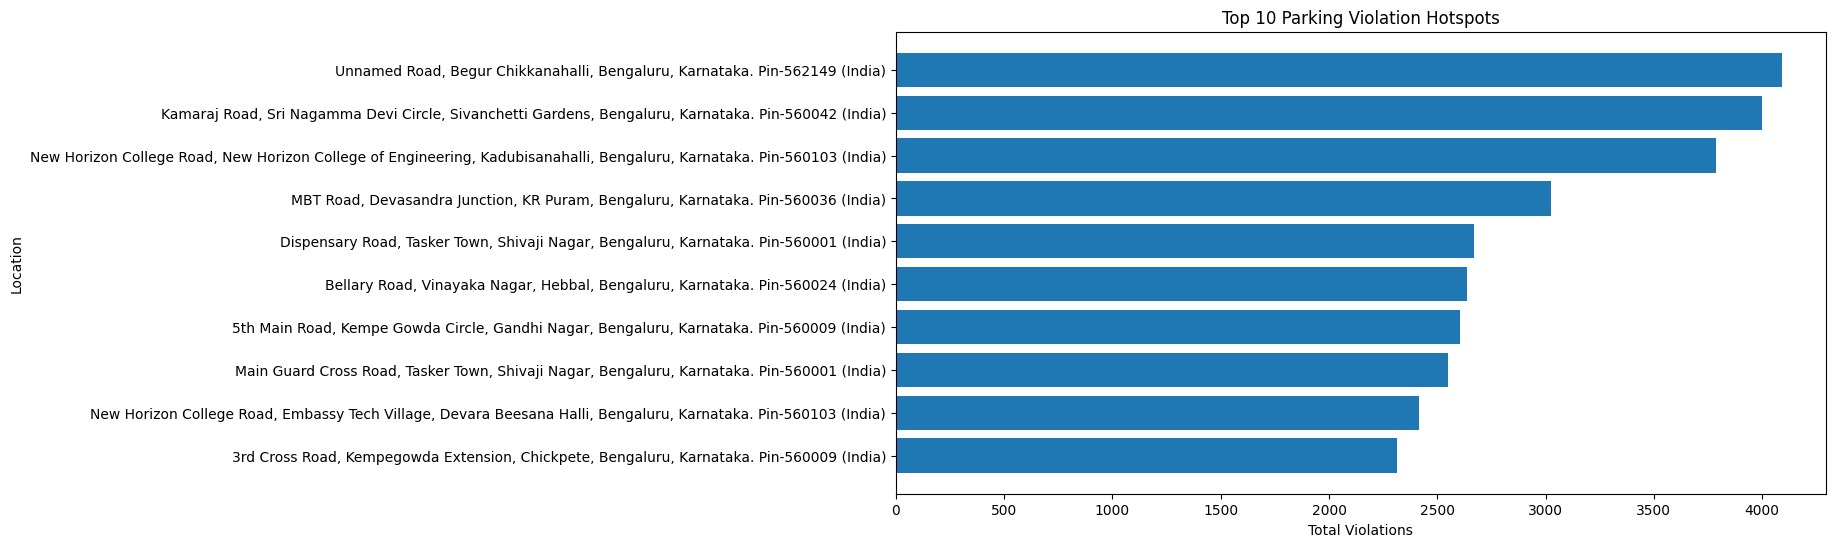

In [36]:
import matplotlib.pyplot as plt

top10 = hotspots.head(10)

plt.figure(figsize=(12,6))
plt.barh(
    top10["location"],
    top10["total_violations"]
)

plt.xlabel("Total Violations")
plt.ylabel("Location")
plt.title("Top 10 Parking Violation Hotspots")

plt.gca().invert_yaxis()

plt.show()

In [37]:
hotspots.head(20)

,rank,location,total_violations,hotspot_score,severity
0,1,"Unnamed Road, Begur Chikkanahalli, Bengaluru, ...",4090,100.00,CRITICAL
1,2,"Kamaraj Road, Sri Nagamma Devi Circle, Sivanch...",3999,97.78,CRITICAL
2,3,"New Horizon College Road, New Horizon College ...",3785,92.54,CRITICAL
3,4,"MBT Road, Devasandra Junction, KR Puram, Benga...",3027,74.01,HIGH
4,5,"Dispensary Road, Tasker Town, Shivaji Nagar, B...",2670,65.28,HIGH
5,6,"Bellary Road, Vinayaka Nagar, Hebbal, Bengalur...",2639,64.52,HIGH
6,7,"5th Main Road, Kempe Gowda Circle, Gandhi Naga...",2604,63.67,HIGH
7,8,"Main Guard Cross Road, Tasker Town, Shivaji Na...",2549,62.32,HIGH
8,9,"New Horizon College Road, Embassy Tech Village...",2416,59.07,HIGH
9,10,"3rd Cross Road, Kempegowda Extension, Chickpet...",2315,56.60,HIGH


In [38]:
hotspots.to_csv(
    "hotspots.csv",
    index=False
)

In [39]:
heatmap_data = df.groupby(
    ["location", "latitude", "longitude"]
).size().reset_index(name="total_violations")

heatmap_data.head()

,location,latitude,longitude,total_violations
0,"1, 10th Main Road, Achaiah Chetty Layout, Sada...",13.011134,77.583562,1
1,"1, 12th Main Road, Sector 6, HSR Layout, Benga...",12.915555,77.636899,1
2,"1, 14th Main Road, Sector 7, HSR Layout, Benga...",12.912080,77.638002,6
3,"1, 7th C Cross Road, Maistripalaya, Kormangala...",12.932624,77.623365,1
4,"1/1, East Park Road, Sadashivanagar, Sadashiva...",13.008388,77.570650,1


In [40]:
heatmap_data.to_csv(
    "heatmap_data.csv",
    index=False
)

In [41]:
hotspot_details = hotspots.copy()

hotspot_details["description"] = (
    "High parking violation zone requiring enforcement attention."
)

hotspot_details.head()

,rank,location,total_violations,hotspot_score,severity,description
0,1,"Unnamed Road, Begur Chikkanahalli, Bengaluru, ...",4090,100.00,CRITICAL,High parking violation zone requiring enforcem...
1,2,"Kamaraj Road, Sri Nagamma Devi Circle, Sivanch...",3999,97.78,CRITICAL,High parking violation zone requiring enforcem...
2,3,"New Horizon College Road, New Horizon College ...",3785,92.54,CRITICAL,High parking violation zone requiring enforcem...
3,4,"MBT Road, Devasandra Junction, KR Puram, Benga...",3027,74.01,HIGH,High parking violation zone requiring enforcem...
4,5,"Dispensary Road, Tasker Town, Shivaji Nagar, B...",2670,65.28,HIGH,High parking violation zone requiring enforcem...


In [42]:
hotspot_details.to_csv(
    "hotspot_details.csv",
    index=False
)

In [43]:
import json

features = []

for _, row in heatmap_data.iterrows():
    features.append({
        "type": "Feature",
        "geometry": {
            "type": "Point",
            "coordinates": [
                row["longitude"],
                row["latitude"]
            ]
        },
        "properties": {
            "location": row["location"],
            "total_violations": int(row["total_violations"])
        }
    })

geojson = {
    "type": "FeatureCollection",
    "features": features
}

with open("hotspots_geojson.json", "w") as f:
    json.dump(geojson, f)